# Evaluation of Batch Correction using Flow-based Density Ratio Estimators.


## Prepare the notebook.

### Autoreload notebook.

In [1]:
%load_ext autoreload
%autoreload 2

### Import the libraries.

In [2]:
import os

import lightning as L
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import scvi
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
import torch
from torchdyn.core import NeuralODE
from tqdm.auto import tqdm 

from utils import ConditionalFlowMatchingWithScore
from scFM_density_estimation.models import NODEWrapper

torch.set_float32_matmul_precision('medium')

### Constants and Paths.

In [3]:
DATA_DIR = "/lustre/groups/ml01/workspace/alessandro.palma/celldreamer/datasets/processed_full_genome/c_elegans"
FULL_H5AD_PATH = os.path.join(DATA_DIR, "c_elegans.h5ad")
TRAIN_H5AD_PATH = os.path.join(DATA_DIR, "c_elegans_train.h5ad")
TEST_H5AD_PATH = os.path.join(DATA_DIR, "c_elegans_test.h5ad")

LAYERS_KEY = "X_counts"
BATCH_KEY = "batch"
LABELS_KEY = "cell_type"

USE_HVG_ONLY = True
USE_SYSVI = True

## Read Data.

### Load `.h5ad` files into memory.

In [4]:
adata_full = sc.read_h5ad(FULL_H5AD_PATH)
adata_train = sc.read_h5ad(TRAIN_H5AD_PATH)
adata_test = sc.read_h5ad(TEST_H5AD_PATH)
print(f"{adata_full=}\n{adata_train=}\n{adata_test=}")

adata_full=AnnData object with n_obs × n_vars = 89701 × 17747
    obs: 'cell', 'numi', 'time_point', 'batch', 'size_factor', 'cell_type', 'cell_subtype', 'plot_cell_type', 'raw_embryo_time', 'embryo_time', 'embryo_time_bin', 'raw_embryo_time_bin', 'lineage', 'passed_qc'
    var: 'gene_id', 'gene_name', 'gene_description', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cell_type_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'X_counts'
    obsp: 'connectivities', 'distances'
adata_train=AnnData object with n_obs × n_vars = 71760 × 17747
    obs: 'cell', 'numi', 'time_point', 'batch', 'size_factor', 'cell_type', 'cell_subtype', 'plot_cell_type', 'raw_embryo_time', 'embryo_time', 'embryo_time_bin', 'raw_embryo_time_bin', 'lineage', 'passed_qc'
    var: 'gene_id', 'gene_name', 'gene_description', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'va

### Visualize cell states.

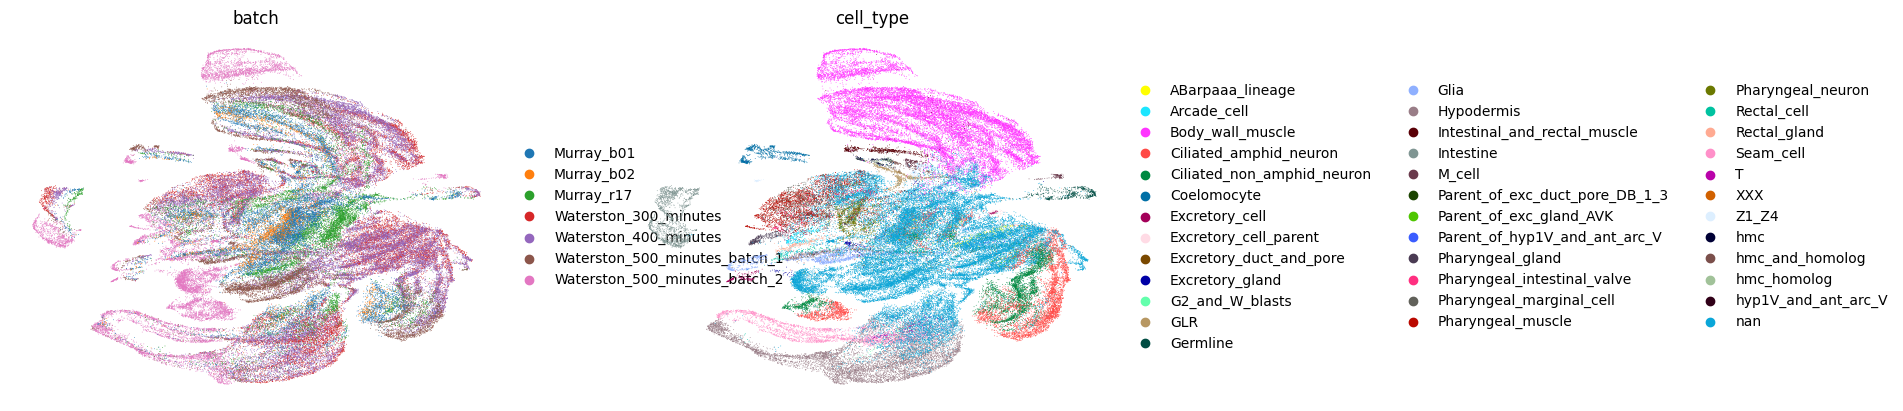

In [5]:
sc.pl.embedding(adata_full, "umap", color=["batch", "cell_type"], frameon=False)

### Inspect batch labels.

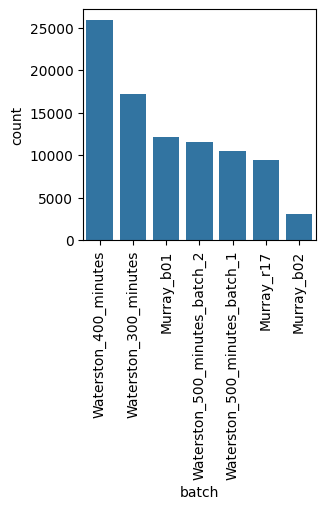

In [6]:
order = adata_full.obs["batch"].value_counts().index
plt.figure(figsize=(3, 3))
sns.countplot(data=adata_full.obs, x="batch", order=order)
plt.tick_params("x", rotation=90)

### Inspect cell type labels.

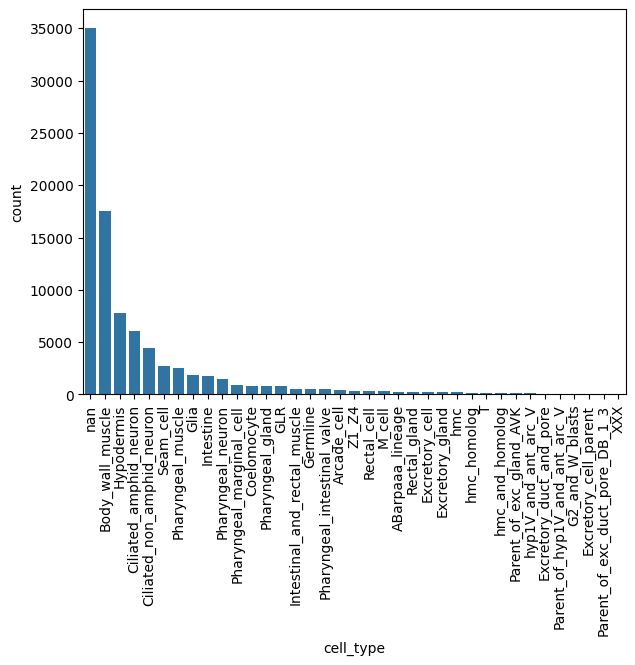

In [7]:
order = adata_full.obs["cell_type"].value_counts().index
plt.figure(figsize=(7, 5))
sns.countplot(data=adata_full.obs, x="cell_type", order=order)
plt.tick_params("x", rotation=90)

### Select Highly Variable Genes.

In [8]:
if USE_HVG_ONLY:
    adata_full = adata_full[:, adata_full.var["highly_variable"]]

### Convert data to sparse.

In [9]:
if LAYERS_KEY is not None:
    if sp.issparse(adata_full.layers[LAYERS_KEY]):
        adata_full.layers[LAYERS_KEY] = adata_full.layers[LAYERS_KEY].tocsr()

/tmp/ipykernel_1962678/502236238.py:3: ImplicitModificationWarning: Setting element `.layers['X_counts']` of view, initializing view as actual.
  adata_full.layers[LAYERS_KEY] = adata_full.layers[LAYERS_KEY].tocsr()


### Plots variance ratio.

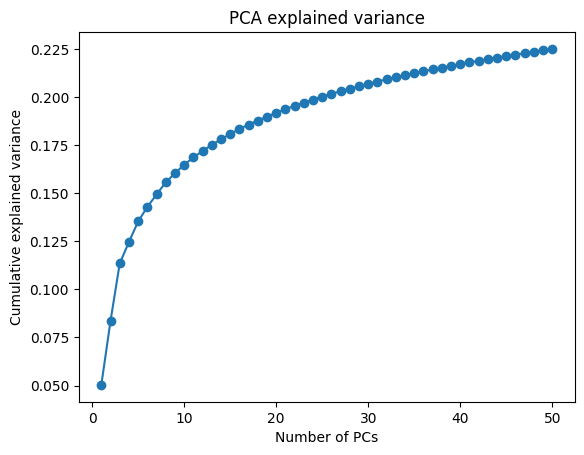

In [10]:
var = adata_full.uns["pca"]["variance_ratio"]
cum_var = np.cumsum(var)

plt.figure()
plt.plot(range(1, len(var)+1), cum_var, marker="o")
plt.xlabel("Number of PCs")
plt.ylabel("Cumulative explained variance")
plt.title("PCA explained variance")
plt.show()


## Fit SCVI.


### Train Model.

In [11]:
scvi.model.SCVI.setup_anndata(
    adata_full,
    layer=LAYERS_KEY,
    batch_key=BATCH_KEY,
    labels_key=LABELS_KEY
)
model = scvi.model.SCVI(
    adata_full,
)
plan_kwargs={
    "optimizer": "AdamW",
    "kl_weight": 0.1,
    "lr": 5e-4,
    "n_epochs_kl_warmup": 50
}
model.train(
    # max_epochs=20,
    plan_kwargs=plan_kwargs,
    validation_size=0.3,
    train_size=0.7,
    check_val_every_n_epoch=1,
)

/home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_density/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_de ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_density/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_de ...
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_density/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data

Training:   0%|          | 0/89 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=89` reached.


### Plot training dynamics.

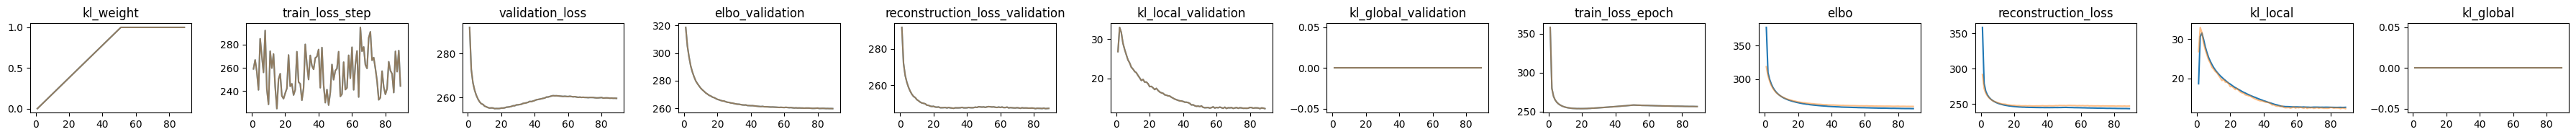

In [12]:
# Make detailed plot after N epochs
epochs_detail_plot = 100

# Losses to plot
losses = list(model.trainer.logger.history.keys())
fig, axs = plt.subplots(1, len(losses), figsize=(len(losses) * 3, 2))
for ax_i, l_train in enumerate(losses):
    l_val = l_train.replace("_train", "_validation")
    l_name = l_train.replace("_train", "")
    # Change idx of epochs to start with 1
    l_val_values = model.trainer.logger.history[l_val].copy()
    l_val_values.index = l_val_values.index + 1
    l_train_values = model.trainer.logger.history[l_train].copy()
    l_train_values.index = l_train_values.index + 1
    for l_values, c, alpha, dp in [
        (l_train_values, "tab:blue", 1, epochs_detail_plot),
        (l_val_values, "tab:orange", 0.5, epochs_detail_plot),
    ]:
        axs[ax_i].plot(l_values.index, l_values.values.ravel(), c=c, alpha=alpha)
        axs[ax_i].set_title(l_name)
        # axs[1, ax_i].plot(l_values.index[dp:], l_values.values.ravel()[dp:], c=c, alpha=alpha)

fig.tight_layout()

### Visualize embeddings.

In [84]:
adata_full.obsm[SCVI_LATENT_KEY].shape 

(89701, 10)

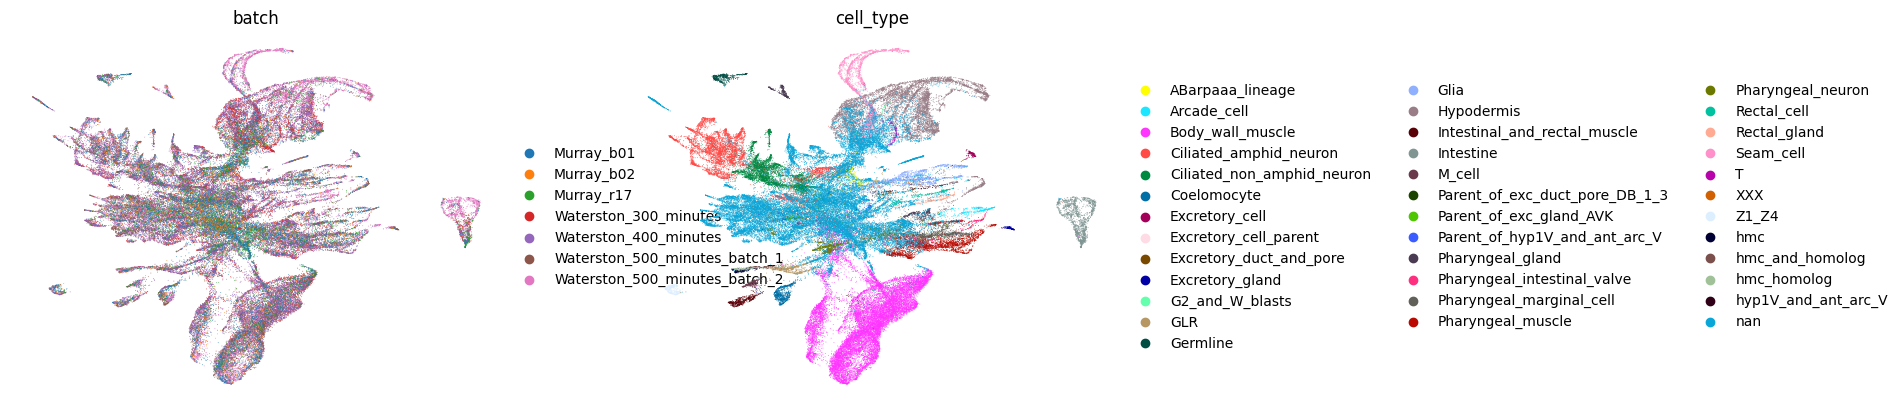

In [13]:
NEIGHBORS_KEY = "scVI_neighbors"
UMAP_KEY = "X_umap_scVI"
SCVI_LATENT_KEY = "X_scVI"

adata_full.obsm[SCVI_LATENT_KEY] = model.get_latent_representation()
sc.pp.neighbors(adata_full, use_rep=SCVI_LATENT_KEY, key_added=NEIGHBORS_KEY)
sc.tl.umap(adata_full, neighbors_key=NEIGHBORS_KEY, key_added=UMAP_KEY, min_dist=0.3)
sc.pl.embedding(adata_full, UMAP_KEY, color=["batch", "cell_type"], frameon=False)


## Fit flow model on uncorrected data.

### Prepare PCs.

In [91]:
N_pcs = adata_full.obsm[SCVI_LATENT_KEY].shape[1]
sc.pp.pca(adata_train, n_comps=N_pcs) # take the full data
adata_train

AnnData object with n_obs × n_vars = 71760 × 17747
    obs: 'cell', 'numi', 'time_point', 'batch', 'size_factor', 'cell_type', 'cell_subtype', 'plot_cell_type', 'raw_embryo_time', 'embryo_time', 'embryo_time_bin', 'raw_embryo_time_bin', 'lineage', 'passed_qc'
    var: 'gene_id', 'gene_name', 'gene_description', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cell_type_colors', 'log1p', 'neighbors', 'pca', 'umap', 'batch_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'X_counts'
    obsp: 'connectivities', 'distances'

### Visualize data.

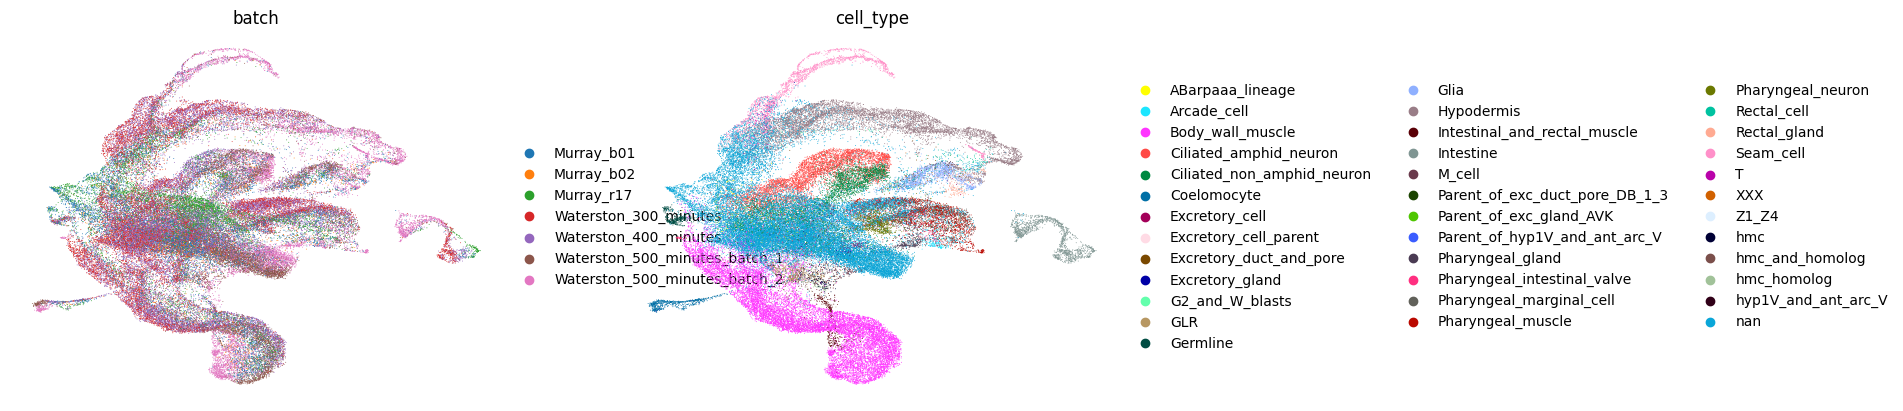

In [15]:
sc.pp.neighbors(adata_train)
sc.tl.umap(adata_train)
sc.pl.embedding(adata_train, "umap", color=["batch", "cell_type", ], frameon=False)


### Prepare Flow Model.

In [92]:
sigma = 0.5
sigma_min = 1e-2
lambda_t = lambda t: torch.sqrt((1 - (1 - sigma_min) * t) ** 2 + sigma * t * (1 - t))
lambda_sp_t = lambda t: (sigma * (1 - 2 * t) - 2 * (1 - sigma_min) * (1 - (1 - sigma_min) * t)) / 2

model = ConditionalFlowMatchingWithScore(
    input_dim=N_pcs,
    cond_dims=[adata_train.obs["cell_type"].nunique(), adata_train.obs["batch"].nunique()],
    hidden_dims=[1024, 1024, 1024],
    encoder_hidden_dims=[256],
    encoder_out_dim=50,
    lambda_t=lambda_t,
    lambda_sp_t=lambda_sp_t,
    betas=[0.0, 0.0]
).to("cuda")
optimizer = model.configure_optimizers()

### Train Model.

In [93]:
X_train = torch.from_numpy(adata_train.obsm["X_pca"]).float().cuda()
C_train = np.concatenate(
    (
        OneHotEncoder().fit_transform(adata_train.obs[["cell_type"]]).toarray(),
        OneHotEncoder().fit_transform(adata_train.obs[["batch"]]).toarray(),
    ), axis=1
)
C_train = torch.from_numpy(C_train).float().cuda()

n_steps = 100_000
batch_size = 1024

loss_history = []
pbar = tqdm(range(n_steps))
ema_loss = None

for k in pbar:
    optimizer.zero_grad()

    indices = np.random.choice(range(X_train.shape[0]), size=batch_size, replace=False)
    loss = model.shared_step(X_train[indices], C_train[indices])
    
    loss.backward()
    optimizer.step()

    if ema_loss is None:
        ema_loss = loss.item()
    else:
        ema_loss = alpha * ema_loss + (1 - alpha) * loss.item() 
    loss_history.append(ema_loss)

    if (k + 1) % 100 == 0:
        pbar.set_description(f"Step {k+1}, EMA Loss: {ema_loss:.3f}")
        pbar.update()

  0%|          | 0/100000 [00:00<?, ?it/s]

### Get unique conditions in train set.

In [94]:
unique_conds = torch.unique(C_train, dim=0)
unique_conds.shape

torch.Size([245, 44])

### Try generation with flow model on each unique train condition.

In [95]:
n_samples = 10_000
samples_dict = {}
for idx in tqdm(range(unique_conds.shape[0])):
    C = unique_conds[idx].unsqueeze(0).repeat(n_samples, 1)
    node = NeuralODE(
        NODEWrapper(model=model, cond=C, use_conds=[True, True], return_score=False),
        solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
    )

    with torch.no_grad():
        traj = node.trajectory(
            torch.randn((n_samples, X_train.shape[1])).float().cuda(),
            t_span=torch.linspace(0, 1, 100).to("cuda")
        )
    samples = traj[-1]
    samples_dict[idx] = samples.detach().cpu().numpy()
    break

  0%|          | 0/245 [00:00<?, ?it/s]

### Decode Samples with PCA.

In [99]:
decode_samples = False
decoded_samples = {}
for idx, samples in tqdm(samples_dict.items()):
    if decode_samples:
        dec_samples = torch.einsum("nk,dk->nd", torch.from_numpy(samples).float().cuda(),
            torch.from_numpy(adata_train.varm["PCs"]).float().cuda()) + torch.from_numpy(adata_train.var.means.values).float().cuda()
        decoded_samples[idx] = dec_samples.detach().cpu().numpy()
    else:
        decoded_samples[idx] = samples
    break

  0%|          | 0/1 [00:00<?, ?it/s]

### Visualize generated samples.

In [101]:
adata_pred_dict = {}
X_train = adata_train.X.toarray() if decode_samples else adata_train.obsm["X_pca"]
for idx, dec_samples in decoded_samples.items():
    C = unique_conds[idx].cpu().numpy()
    C_mask_train = np.all(C_train.detach().cpu().numpy() == C, axis=1)
    C_mask_gen = np.full((n_samples, ), fill_value=True)
    C_mask = np.concatenate((C_mask_train, C_mask_gen), axis=0)
    X = np.concat(
        (X_train, dec_samples), axis=0
    )
    adata_gen = sc.AnnData(
        X=X,
        obs={"is_target_c": C_mask, "is_gen": np.concatenate((np.full((X_train.shape[0], ), fill_value=False), np.full((n_samples, ), fill_value=True)), axis=0)},
    )
    if decode_samples:
        sc.pp.pca(adata_gen)
    sc.pp.neighbors(adata_gen)
    sc.tl.umap(adata_gen)
    adata_pred_dict[idx] = adata_gen
    break


### Compare generated PCs to real ones from the same group.

<Axes: ylabel='Count'>

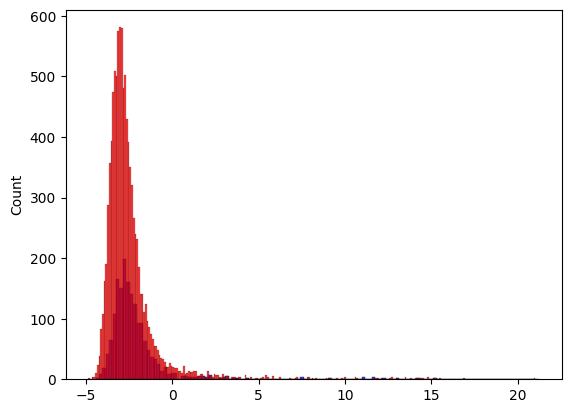

In [104]:
sns.histplot(adata_train.obsm["X_pca"][C_mask_train, 0], color="blue")
sns.histplot(samples[:, 0], color="red")

### Visualizing samples.

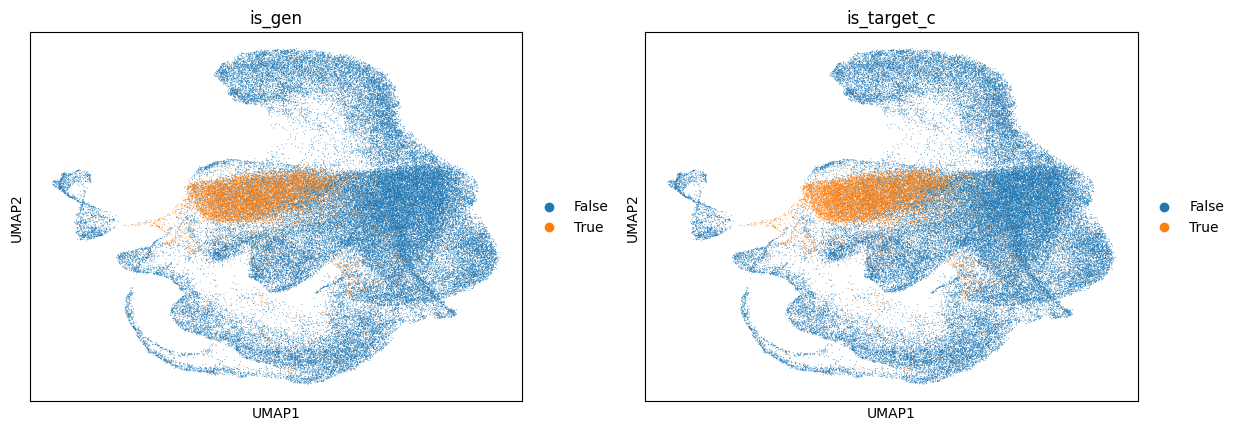

In [105]:
for idx, adata_gen in adata_pred_dict.items():
    sc.pl.embedding(adata_gen, "umap", color=["is_gen", "is_target_c"])

## Fit Flow Model on Corrected Representations.